In [8]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ruta_base = "dataset/Training_LR_CLAHE_escala2/s1"

archivos = sorted(os.listdir(ruta_base))
print(f"Archivos encontrados: {archivos}")

Archivos encontrados: ['1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']


 1.png → shape: (112, 92)
 2.png → shape: (112, 92)
 3.png → shape: (112, 92)
 4.png → shape: (112, 92)
 5.png → shape: (112, 92)


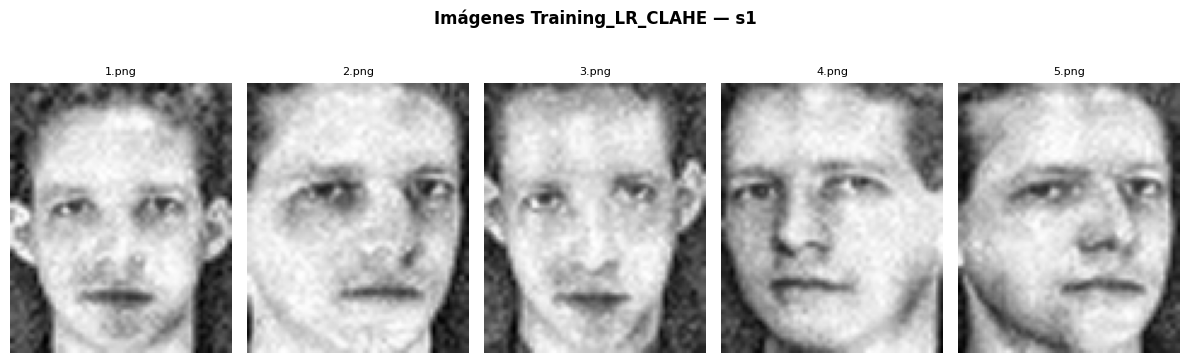

In [3]:
plt.figure(figsize=(12, 4))

for i, archivo in enumerate(archivos[:5]):
    ruta = os.path.join(ruta_base, archivo)
    img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f" No cargó: {archivo}")
        continue

    print(f" {archivo} → shape: {img.shape}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(archivo, fontsize=8)
    plt.axis('off')

plt.suptitle("Imágenes Training_LR_CLAHE — s1", fontweight='bold')
plt.tight_layout()
plt.show()

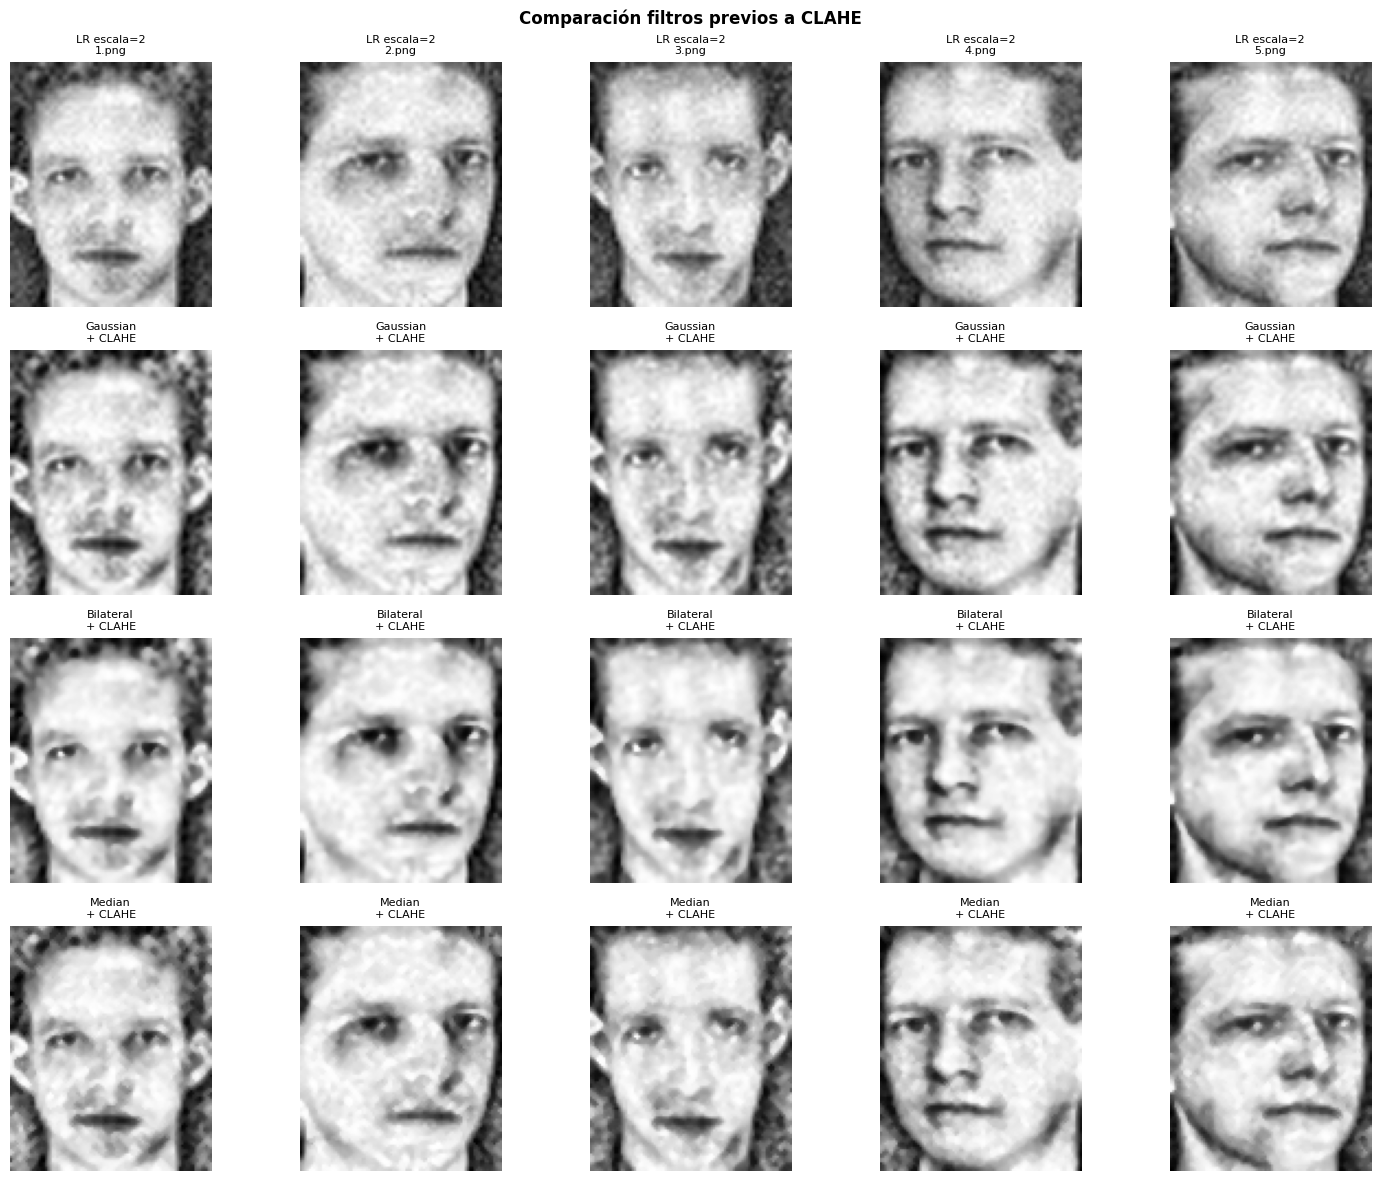

In [5]:
ruta_base = "dataset/Training_LR_CLAHE_escala2/s1"
archivos  = sorted(os.listdir(ruta_base))

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

plt.figure(figsize=(15, 12))

for i, archivo in enumerate(archivos[:5]):
    ruta = os.path.join(ruta_base, archivo)
    img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # ── Opción A: Gaussian suave → CLAHE ─────────────────────────────────
    img_gaussian = cv2.GaussianBlur(img, (3, 3), sigmaX=0.8)
    img_clahe_a  = clahe.apply(img_gaussian)

    # ── Opción B: Bilateral → CLAHE (preserva bordes) ────────────────────
    img_bilateral = cv2.bilateralFilter(img, d=5, sigmaColor=30, sigmaSpace=30)
    img_clahe_b   = clahe.apply(img_bilateral)

    # ── Opción C: Median → CLAHE (elimina ruido sal y pimienta) ──────────
    img_median   = cv2.medianBlur(img, 3)
    img_clahe_c  = clahe.apply(img_median)

    # Fila 1: LR original
    plt.subplot(4, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"LR escala=2\n{archivo}", fontsize=8)
    plt.axis('off')

    # Fila 2: Gaussian + CLAHE
    plt.subplot(4, 5, i + 6)
    plt.imshow(img_clahe_a, cmap='gray')
    plt.title(f"Gaussian\n+ CLAHE", fontsize=8)
    plt.axis('off')

    # Fila 3: Bilateral + CLAHE
    plt.subplot(4, 5, i + 11)
    plt.imshow(img_clahe_b, cmap='gray')
    plt.title(f"Bilateral\n+ CLAHE", fontsize=8)
    plt.axis('off')

    # Fila 4: Median + CLAHE
    plt.subplot(4, 5, i + 16)
    plt.imshow(img_clahe_c, cmap='gray')
    plt.title(f"Median\n+ CLAHE", fontsize=8)
    plt.axis('off')

plt.suptitle("Comparación filtros previos a CLAHE", fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
def clahe_con_mascara(imagen_gray, clip_limit=2.0, tile_grid_size=(8, 8)):

    _, mascara_rostro = cv2.threshold(imagen_gray, 15, 255, cv2.THRESH_BINARY)
    mascara_suave     = cv2.GaussianBlur(mascara_rostro, (5, 5), 0)
    mascara_norm      = mascara_suave.astype(np.float32) / 255.0

    # ── Reducir intensidad del bilateral para menos borrosidad ───────────
    img_filtrada = cv2.bilateralFilter(imagen_gray,
                                       d=3,           # era 5 → menos radio
                                       sigmaColor=20, # era 30 → menos suavizado
                                       sigmaSpace=20) # era 30 → más local

    clahe     = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_clahe = clahe.apply(img_filtrada)

    resultado = (img_clahe.astype(np.float32) * mascara_norm +
                 imagen_gray.astype(np.float32) * (1 - mascara_norm))

    return resultado.astype(np.uint8), mascara_rostro

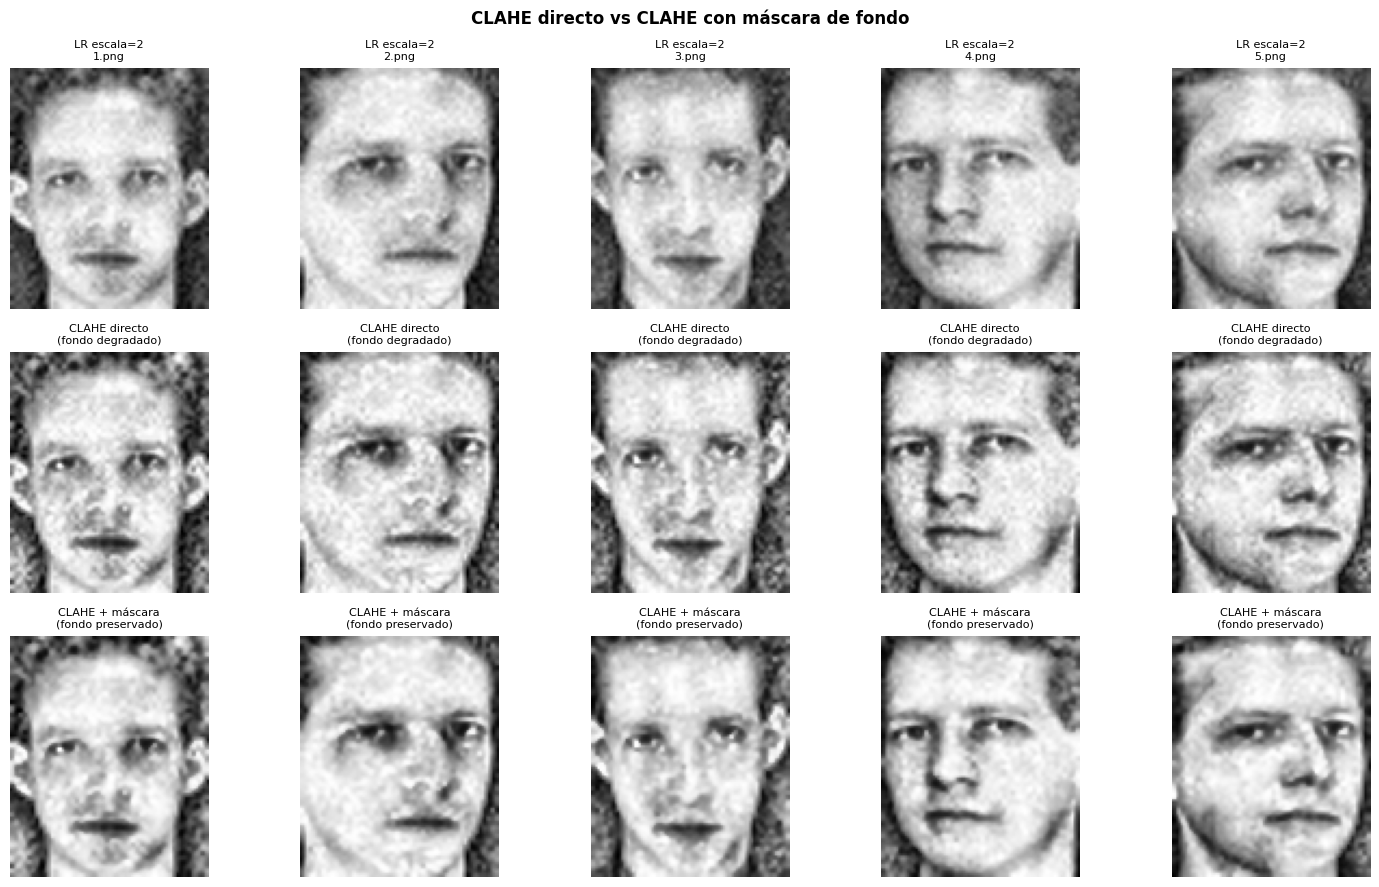

In [11]:
ruta_base = "dataset/Training_LR_CLAHE_escala2/s1"
archivos  = sorted(os.listdir(ruta_base))

plt.figure(figsize=(15, 9))

for i, archivo in enumerate(archivos[:5]):
    ruta = os.path.join(ruta_base, archivo)
    img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    clahe_directo  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    clahe_mascara, mascara = clahe_con_mascara(img)

    # Fila 1: LR original
    plt.subplot(3, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"LR escala=2\n{archivo}", fontsize=8)
    plt.axis('off')

    # Fila 2: CLAHE directo (problema actual)
    plt.subplot(3, 5, i + 6)
    plt.imshow(clahe_directo, cmap='gray')
    plt.title("CLAHE directo\n(fondo degradado)", fontsize=8)
    plt.axis('off')

    # Fila 3: CLAHE con máscara (solución)
    plt.subplot(3, 5, i + 11)
    plt.imshow(clahe_mascara, cmap='gray')
    plt.title("CLAHE + máscara\n(fondo preservado)", fontsize=8)
    plt.axis('off')

plt.suptitle("CLAHE directo vs CLAHE con máscara de fondo", fontweight='bold')
plt.tight_layout()
plt.show()